<a href="https://colab.research.google.com/github/mehranyom/rossmann-sales-forecasting/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import os
import pandas as pd
from pandas.plotting import scatter_matrix
from google.colab import userdata
from pathlib import Path
from kaggle.api.kaggle_api_extended import KaggleApi
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
color_pal = sns.color_palette()
plt.style.use('seaborn-v0_8-whitegrid')

In [4]:
# 1. Safely load Kaggle credentials from Colab Secrets
os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_KEY'] = userdata.get('KAGGLE_KEY')

api = KaggleApi()
api.authenticate()

In [5]:
def load_train_data():
  raw_dir = Path("data/raw")
  train_raw_path = raw_dir / "train.csv"
  if not train_raw_path.is_file():
    print("Dataset not found. Downloading from Kaggle...")
    raw_dir.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(
      'pratyushakar/rossmann-store-sales',
      path=raw_dir,
      unzip=True
    )
    print("Dataset downloaded successfully!")
  else:
    print("Dataset found locally.")

  print("Loading train.csv into memory...")
  return pd.read_csv(train_raw_path, low_memory=False)


In [6]:
def load_store_data():
  raw_dir = Path("data/raw")
  store_raw_path = raw_dir / "store.csv"
  if not store_raw_path.is_file():
    print("Dataset not found. Downloading from Kaggle...")
    raw_dir.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(
      'pratyushakar/rossmann-store-sales',
      path='data/raw/',
      unzip=True
    )
    print("Dataset downloaded successfully!")
  else:
    print("Dataset found locally.")

  print("Loading train.csv into memory...")
  return pd.read_csv(store_raw_path, low_memory=False)


In [7]:
def load_test_data():
  raw_dir = Path("data/raw")
  test_raw_path = raw_dir / "test.csv"
  if not test_raw_path.is_file():
    print("Dataset not found. Downloading from Kaggle...")
    raw_dir.mkdir(parents=True, exist_ok=True)
    api.dataset_download_files(
      'pratyushakar/rossmann-store-sales',
      path='data/raw/',
      unzip=True
    )
    print("Dataset downloaded successfully!")
  else:
    print("Dataset found locally.")

  print("Loading train.csv into memory...")
  return pd.read_csv(test_raw_path, low_memory=False)


In [8]:
train_df = load_train_data()

Dataset not found. Downloading from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales
Dataset downloaded successfully!
Loading train.csv into memory...


In [9]:
store_df = load_store_data()

Dataset found locally.
Loading train.csv into memory...


In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [11]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [12]:
train_df.head(10)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1
5,6,5,2015-07-31,5651,589,1,1,0,1
6,7,5,2015-07-31,15344,1414,1,1,0,1
7,8,5,2015-07-31,8492,833,1,1,0,1
8,9,5,2015-07-31,8565,687,1,1,0,1
9,10,5,2015-07-31,7185,681,1,1,0,1


In [13]:
store_df.head(10)

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
7,8,a,a,7520.0,10.0,2014.0,0,NaN,NaN,NaN
8,9,a,c,2030.0,8.0,2000.0,0,NaN,NaN,NaN
9,10,a,a,3160.0,9.0,2009.0,0,NaN,NaN,NaN


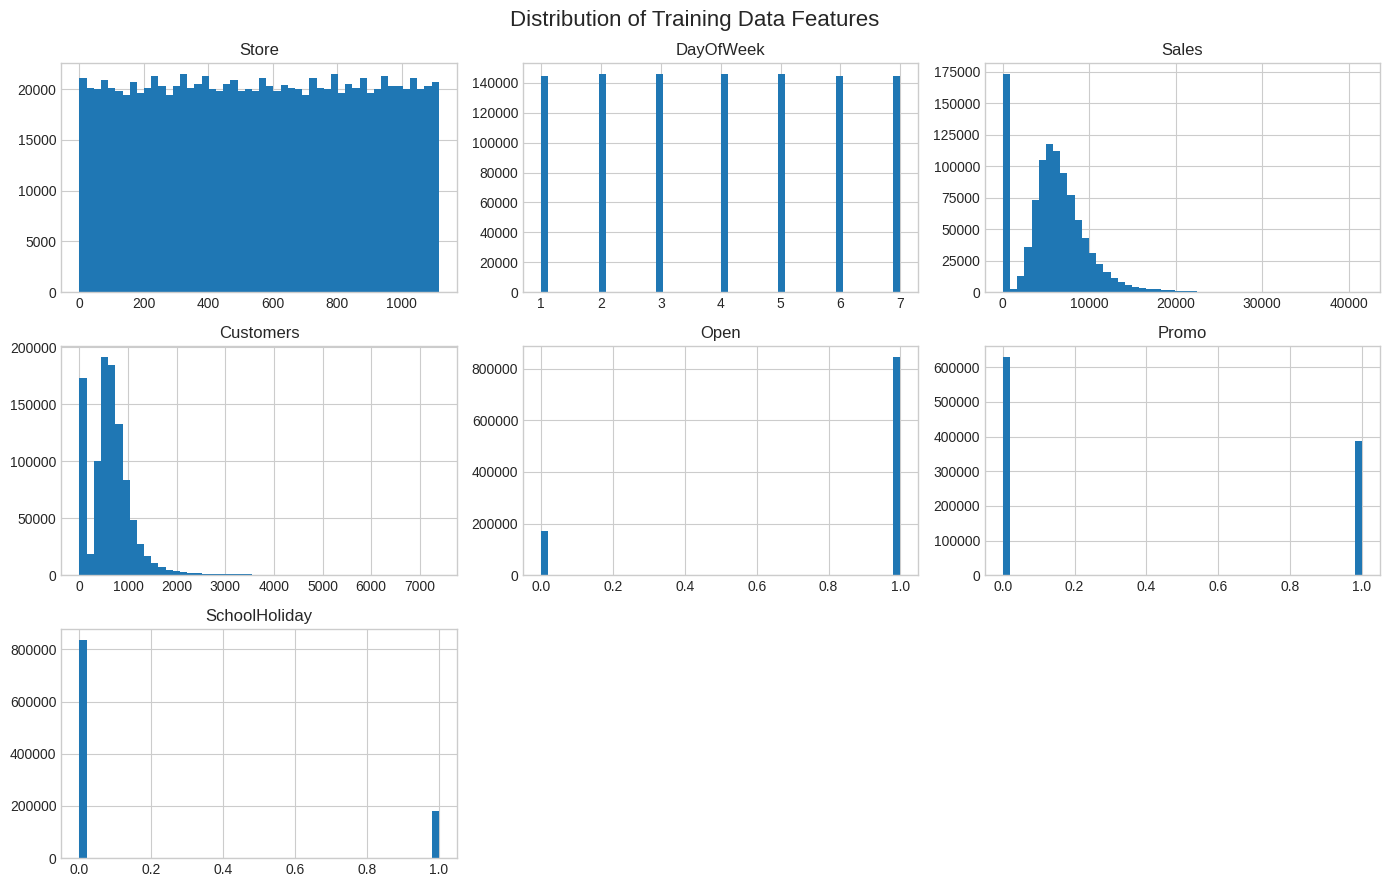

In [14]:
train_df.hist(bins = 50, figsize = (14,9), xlabelsize=10, ylabelsize=10)
plt.suptitle("Distribution of Training Data Features", fontsize=16)
plt.tight_layout()
plt.show()

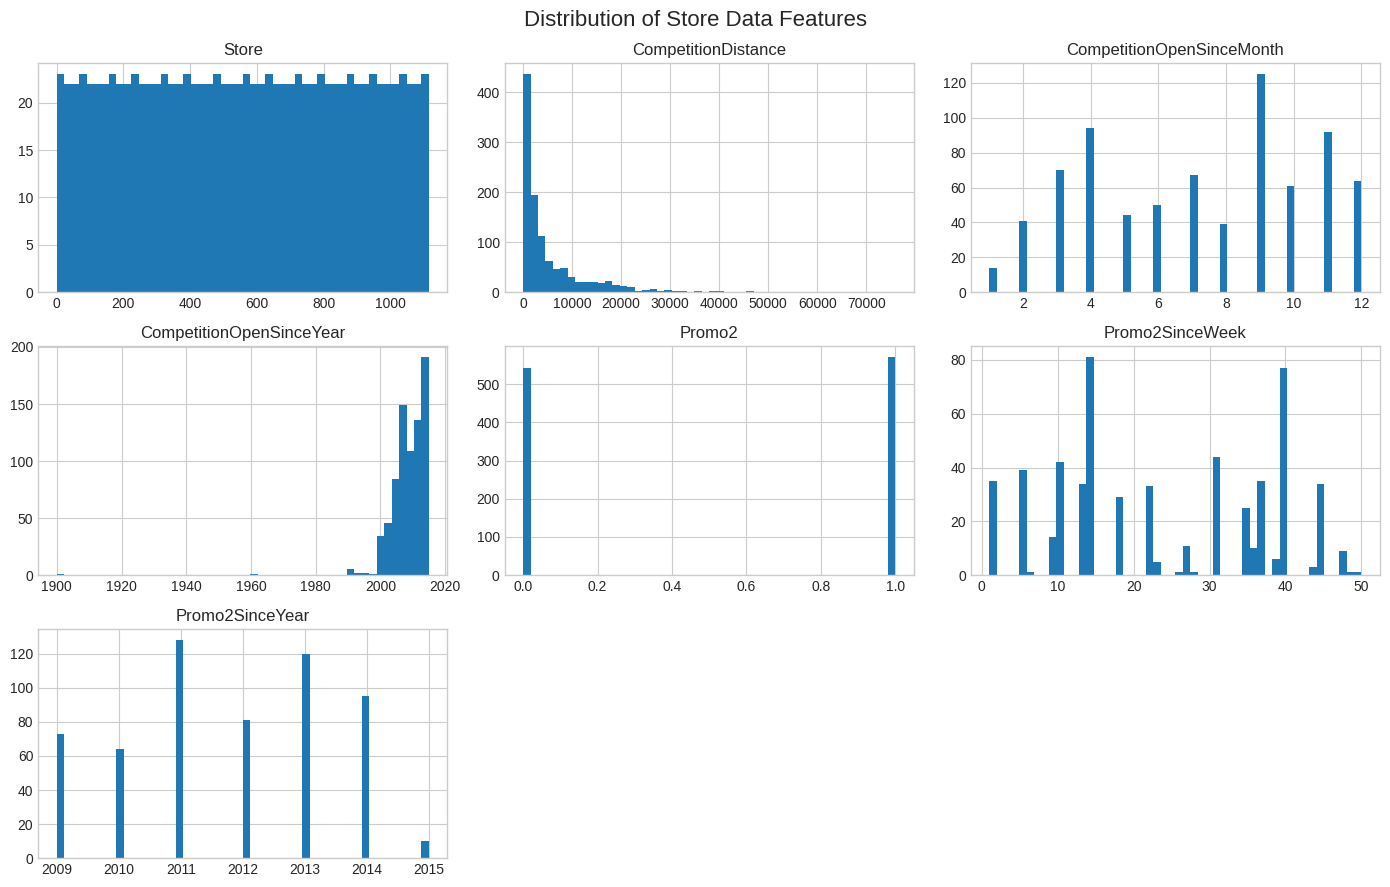

In [15]:
store_df.hist(bins = 50, figsize = (14,9), xlabelsize=10, ylabelsize=10)
plt.suptitle("Distribution of Store Data Features", fontsize=16)
plt.tight_layout()
plt.show()

In [16]:
train_df["Date"].min()

'2013-01-01'

In [17]:
train_df["Date"].max()

'2015-07-31'

In [18]:
daily_sales = train_df.groupby("Date")["Sales"].sum().reset_index()
daily_sales.head()

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [19]:
daily_sales.set_index('Date', inplace=True)

In [20]:
daily_sales.index = pd.to_datetime(daily_sales.index)

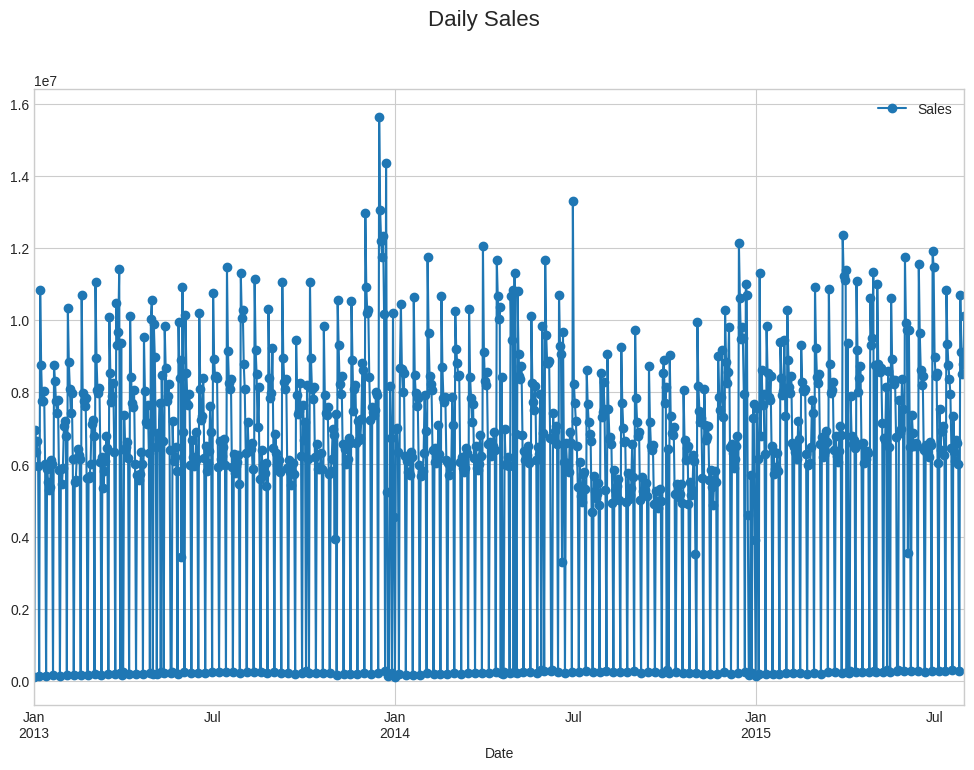

In [21]:
daily_sales.plot(figsize = (12,8), color = color_pal[0], style="o-")
plt.suptitle("Daily Sales", fontsize=16)
plt.show()

In [22]:
weekly_sales = daily_sales['Sales'].resample('W').sum()
weekly_sales.head()

,Sales
Date,
2013-01-06,26129335
2013-01-13,49275222
2013-01-20,34377765
2013-01-27,46040169
2013-02-03,38466029


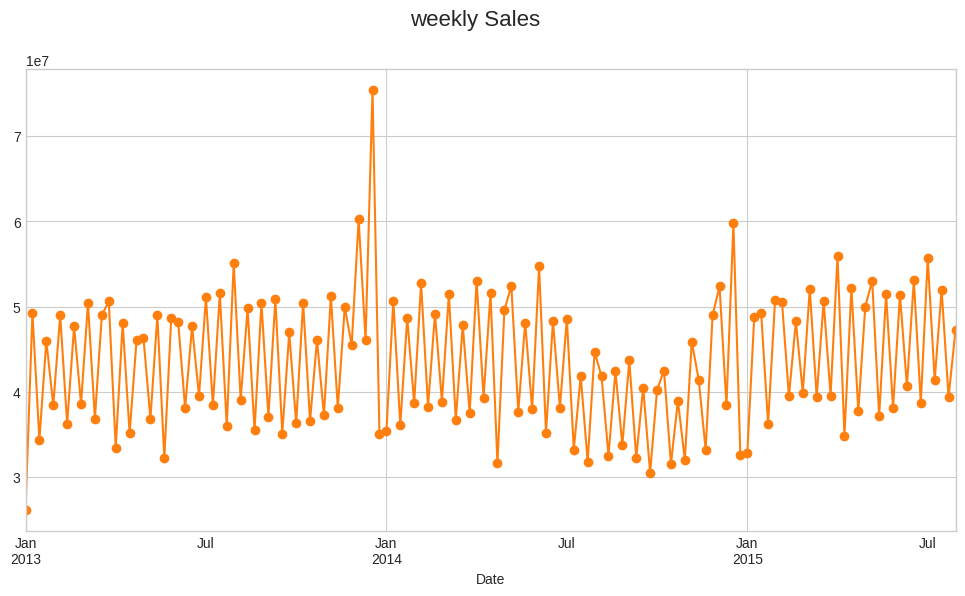

In [23]:
weekly_sales.plot(figsize = (12,6), color = color_pal[1], style="o-", grid=True)
plt.suptitle("weekly Sales", fontsize=16)
plt.show()

In [24]:
monthly_sales = daily_sales['Sales'].resample('ME').sum()
monthly_sales.head()

,Sales
Date,
2013-01-31,180132207
2013-02-28,171534275
2013-03-31,201180369
2013-04-30,183431432
2013-05-31,185411063


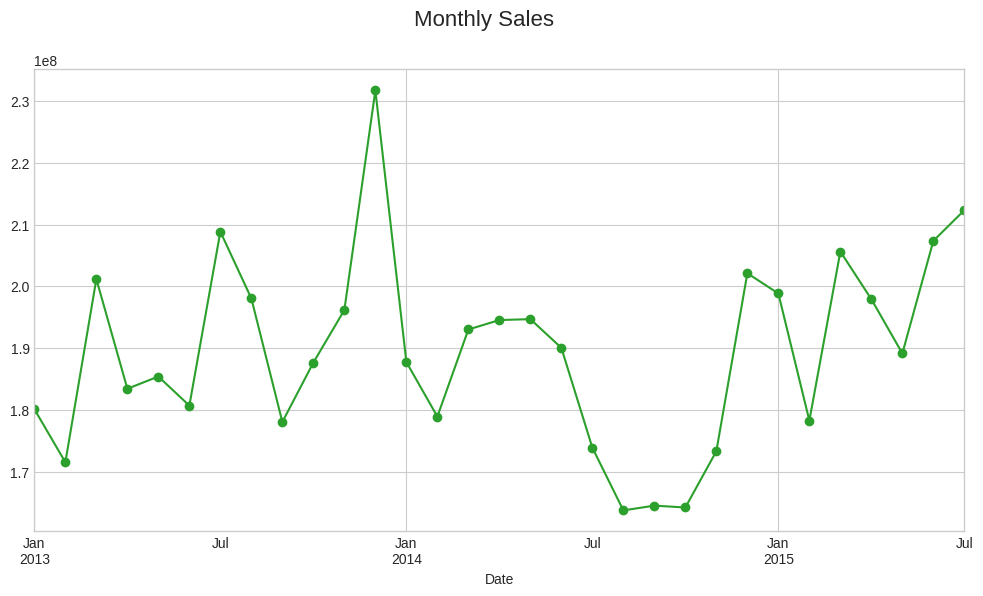

In [25]:
monthly_sales.plot(figsize = (12,6), color = color_pal[2], style="o-", grid=True)
plt.suptitle("Monthly Sales", fontsize=16)
plt.show()

In [26]:
open_train_df = train_df[train_df["Open"] == 1].copy()

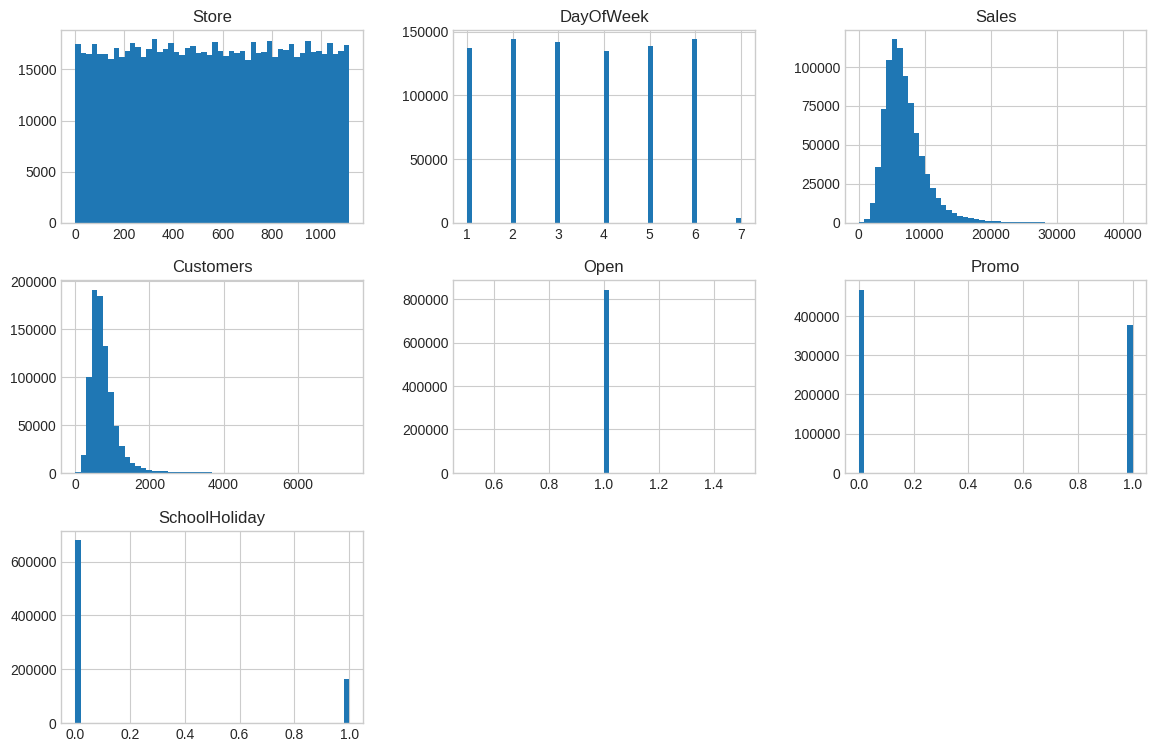

In [27]:
open_train_df.hist(bins = 50, figsize = (14,9), xlabelsize=10, ylabelsize=10)
plt.show()

In [28]:
try:
  open_train_df = open_train_df.drop(columns=["Open"])
except:
  pass

In [29]:
open_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


In [30]:
open_train_df["Date"] = pd.to_datetime(open_train_df["Date"])

In [31]:
df = pd.merge(open_train_df, store_df, on='Store', how='left')
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [32]:
corr_matrix = df.corr(numeric_only=True)

In [33]:
corr_matrix["Sales"].sort_values(ascending=False)

,Sales
Sales,1.000000
Customers,0.823597
Promo,0.368145
Promo2SinceWeek,0.095311
SchoolHoliday,0.038617
CompetitionOpenSinceYear,0.016101
Store,0.007710
Promo2SinceYear,-0.034713
CompetitionDistance,-0.036396
CompetitionOpenSinceMonth,-0.043489


In [34]:
corr_matrix["Customers"].sort_values(ascending=False)

,Customers
Customers,1.000000
Sales,0.823597
Promo,0.182846
Promo2SinceWeek,0.061682
Promo2SinceYear,0.040893
Store,0.033977
SchoolHoliday,0.024902
CompetitionOpenSinceYear,0.010175
CompetitionOpenSinceMonth,-0.044965
DayOfWeek,-0.097266


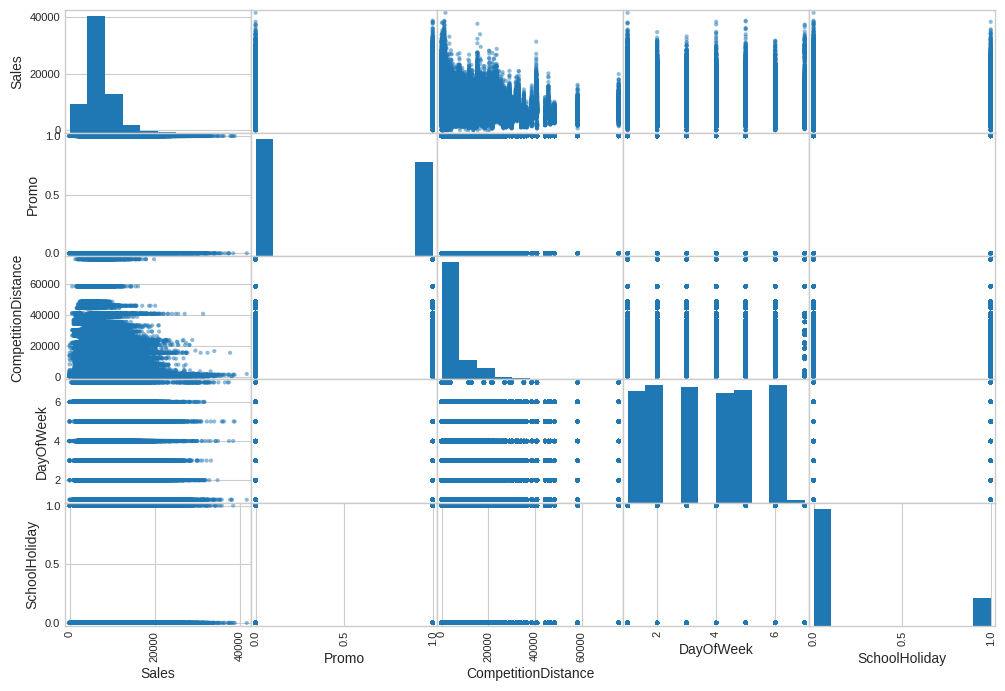

In [35]:
attributes = ["Sales", "Promo", "CompetitionDistance", "DayOfWeek", "SchoolHoliday"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

<Figure size 1200x800 with 0 Axes>

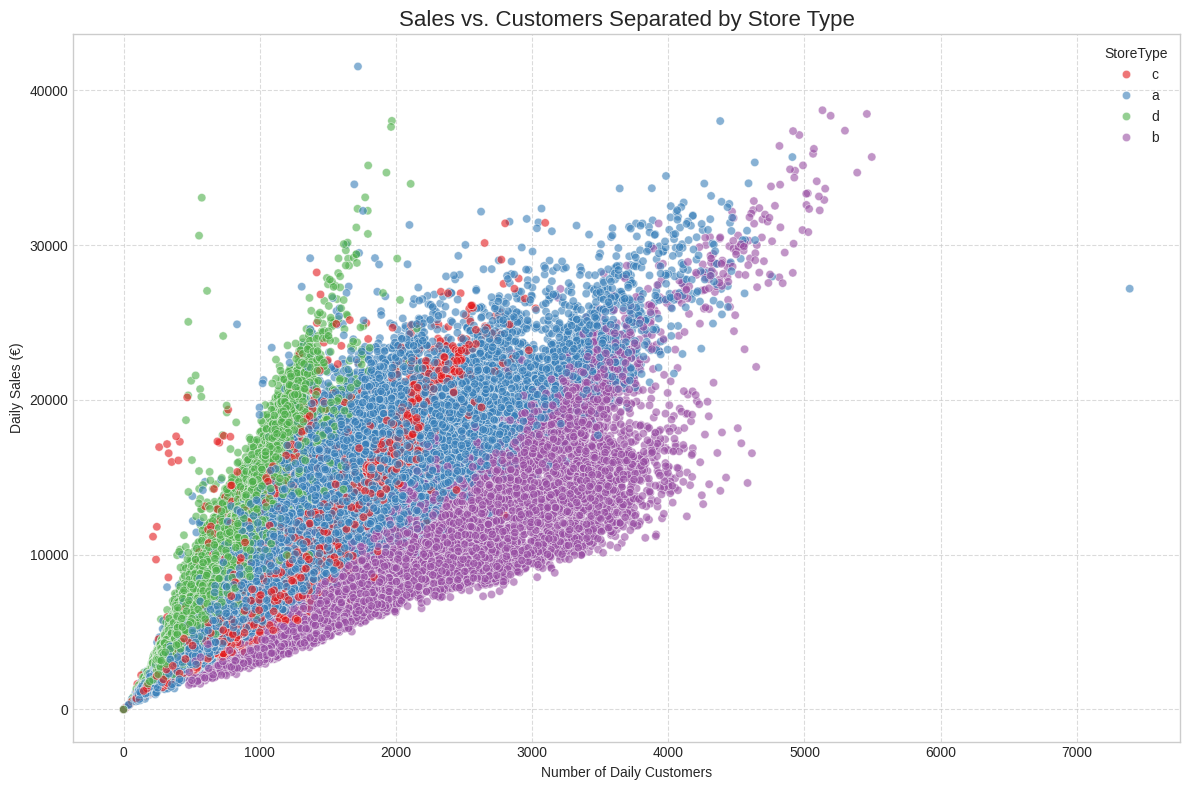

In [48]:
plt.figure(figsize=(12, 8))

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df,
    x='Customers',
    y='Sales',
    hue='StoreType',   # This automatically colors the dots by store type
    alpha=0.6,         # Makes dots slightly transparent to show density
    palette='Set1'     # Uses a distinct, bright color palette
)

plt.title('Sales vs. Customers Separated by Store Type', fontsize=16)
plt.xlabel('Number of Daily Customers')
plt.ylabel('Daily Sales (€)')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

/tmp/ipykernel_1951/2570442785.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


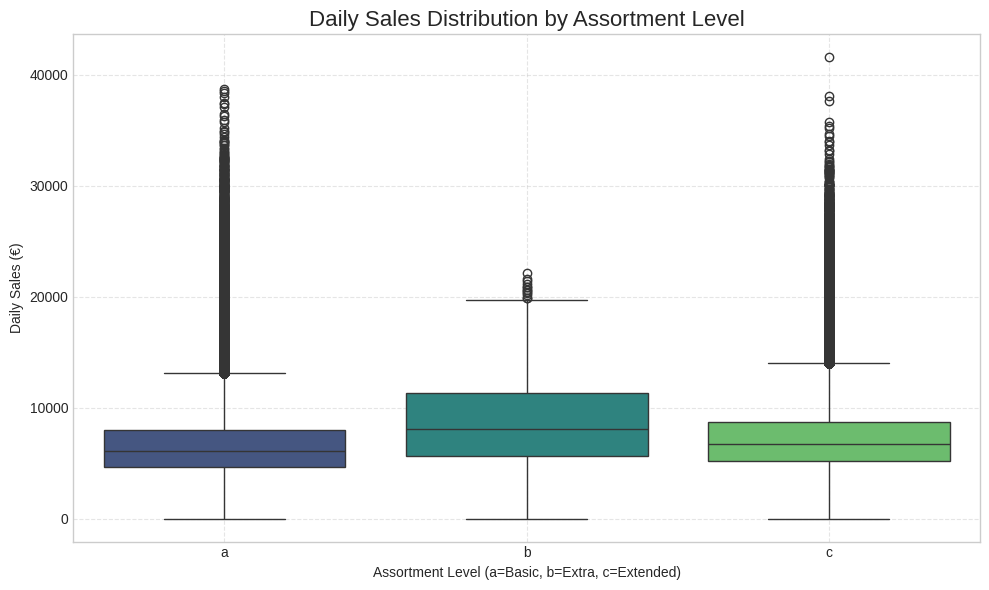

In [38]:
plt.figure(figsize=(10, 6))

# A boxplot clearly shows the median and the revenue spread for each level
sns.boxplot(
    data=df,
    x='Assortment',
    y='Sales',
    palette='viridis',
    order=['a', 'b', 'c'] # Ordering from basic to extended
)

plt.title('Daily Sales Distribution by Assortment Level', fontsize=16)
plt.xlabel('Assortment Level (a=Basic, b=Extra, c=Extended)')
plt.ylabel('Daily Sales (€)')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

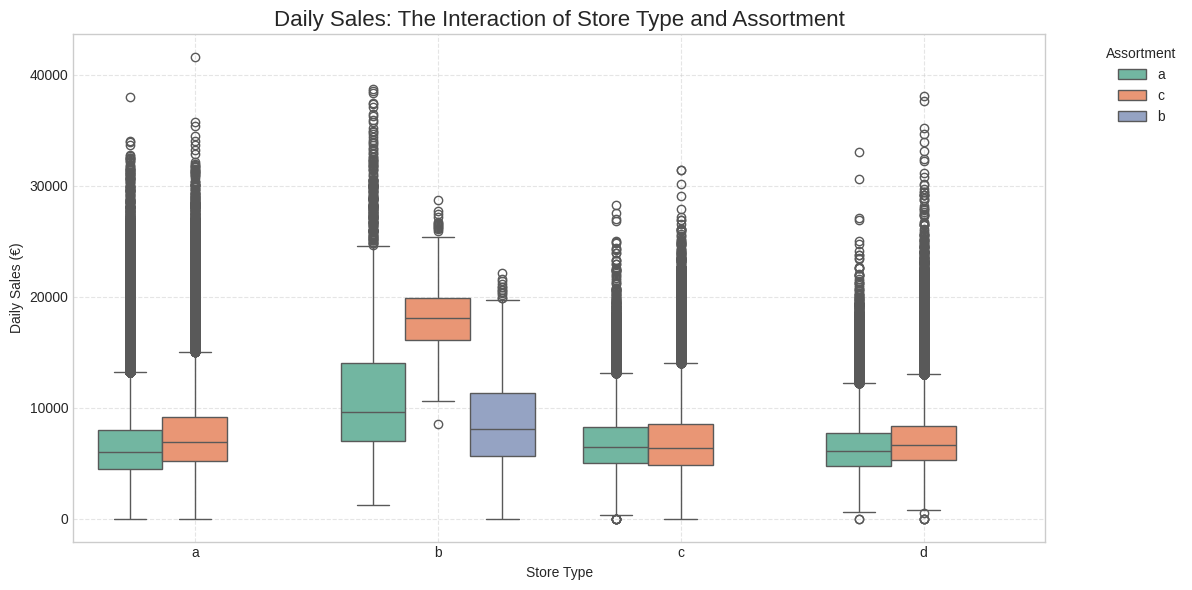

In [39]:
plt.figure(figsize=(12, 6))

# The 'hue' parameter does the heavy lifting here, grouping the assortment inside each store type
sns.boxplot(
    data=df,
    x='StoreType',
    y='Sales',
    hue='Assortment',
    palette='Set2',
    order=['a', 'b', 'c', 'd']
)

plt.title('Daily Sales: The Interaction of Store Type and Assortment', fontsize=16)
plt.xlabel('Store Type')
plt.ylabel('Daily Sales (€)')

# Move the legend outside the plot so it doesn't block the data boxes
plt.legend(title='Assortment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [54]:
# 1. Handle Promo2 columns: Fill structural missing values with 0
promo_cols = ['Promo2SinceWeek', 'Promo2SinceYear']
df[promo_cols] = df[promo_cols].fillna(0)
df[['PromoInterval']] = df[['PromoInterval']].fillna('none')

# 2. Handle Competition Distance: Fill with a massive number (e.g., 2x the max distance)
# This pushes these stores far to the right side of the distribution, away from dense clusters
extreme_distance = df['CompetitionDistance'].max() * 2
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(extreme_distance)

# 3. Handle Competition Open Dates: Fill unknown dates with 0
comp_date_cols = ['CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear']
df[comp_date_cols] = df[comp_date_cols].fillna(0)

# Verify everything is clean (this should print 0 missing values for these columns)
print(df[['Promo2SinceWeek', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'PromoInterval']].isnull().sum())
df.head()

Promo2SinceWeek              0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
PromoInterval                0
dtype: int64


,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,none
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,none
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,none


In [58]:
categorical_cols = ['StoreType', 'Assortment', 'PromoInterval', 'StateHoliday']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   Store                           844392 non-null  int64         
 1   DayOfWeek                       844392 non-null  int64         
 2   Date                            844392 non-null  datetime64[ns]
 3   Sales                           844392 non-null  int64         
 4   Customers                       844392 non-null  int64         
 5   Promo                           844392 non-null  int64         
 6   SchoolHoliday                   844392 non-null  int64         
 7   CompetitionDistance             844392 non-null  float64       
 8   CompetitionOpenSinceMonth       844392 non-null  float64       
 9   CompetitionOpenSinceYear        844392 non-null  float64       
 10  Promo2                          844392 non-null  int64  

In [64]:
# 1. Extract numerical components from the Date column
df_encoded['Year'] = df_encoded['Date'].dt.year
df_encoded['Month'] = df_encoded['Date'].dt.month
df_encoded['Day'] = df_encoded['Date'].dt.day


X_m1 = df_encoded.drop(columns=['Sales', 'Customers', 'Date'])
y_m1_customers = df_encoded['Customers']

split_date = '2015-06-01'

train_mask = df['Date'] < split_date
validation_mask = df['Date'] >= split_date

X_train_m1, X_validation_m1 = X_m1[train_mask], X_m1[validation_mask]
y_train_c, y_validation_c = y_m1_customers[train_mask], y_m1_customers[validation_mask]

print(f"Training set shape: {X_train_m1.shape}")
print(f"Testing set shape: {X_validation_m1.shape}")
X_train_m1.head()

Training set shape: (785781, 24)
Testing set shape: (58611, 24)


,Store,DayOfWeek,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,...,Assortment_c,"PromoInterval_Jan,Apr,Jul,Oct","PromoInterval_Mar,Jun,Sept,Dec",PromoInterval_none,StateHoliday_a,StateHoliday_b,StateHoliday_c,Year,Month,Day
58611,85,7,0,0,1870.0,10.0,2011.0,0,0.0,0.0,...,False,False,False,True,False,False,False,2015,5,31
58612,122,7,0,0,58260.0,4.0,2013.0,0,0.0,0.0,...,True,False,False,True,False,False,False,2015,5,31
58613,209,7,0,0,11680.0,9.0,2011.0,1,31.0,2013.0,...,True,True,False,False,False,False,False,2015,5,31
58614,259,7,0,0,210.0,0.0,0.0,0,0.0,0.0,...,False,False,False,True,False,False,False,2015,5,31
58615,262,7,0,0,1180.0,5.0,2013.0,0,0.0,0.0,...,False,False,False,True,False,False,False,2015,5,31


In [65]:
rf_customers = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_customers.fit(X_train_m1, y_train_c)

RandomForestRegressor(n_estimators=50, n_jobs=-1, random_state=42)

In [66]:
X_train_m1['Predicted_Customers'] = rf_customers.predict(X_train_m1)
X_validation_m1['Predicted_Customers'] = rf_customers.predict(X_validation_m1)

/tmp/ipykernel_1951/2599192763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_m1['Predicted_Customers'] = rf_customers.predict(X_train_m1)
/tmp/ipykernel_1951/2599192763.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_validation_m1['Predicted_Customers'] = rf_customers.predict(X_validation_m1)


In [67]:
y_m2 = df_encoded['Sales']
y_train_s, y_validation_s = y_m2[train_mask], y_m2[validation_mask]

rf_sales = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_sales.fit(X_train_m1, y_train_s)

sales_predictions = rf_sales.predict(X_validation_m1)
final_mae = mean_absolute_error(y_validation_s, sales_predictions)

print(f"Final Two-Stage Model Sales MAE: €{final_mae:.2f}")

Final Two-Stage Model Sales MAE: €717.30


In [69]:
def calculate_rmspe(y_true, y_pred):
    # Filter out zero-sales days (stores closed) to prevent division by zero
    mask = y_true != 0
    return np.sqrt(np.mean(np.square((y_true[mask] - y_pred[mask]) / y_true[mask])))

In [71]:
rmspe = calculate_rmspe(y_validation_s, sales_predictions)
print(f"RMSPE: {rmspe * 100:.2f}%")

RMSPE: 14.91%
